In [1]:
# ── Section 1: Basic Overview ──────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

trans = pd.read_csv('train_transaction.csv')
identity = pd.read_csv('train_identity.csv')

print(trans.shape)          # how many rows, columns
print(trans.dtypes)         # column types
print(trans.isnull().sum()) # missing values per column
print(trans.head())

(590540, 394)
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
V335              float64
V336              float64
V337              float64
V338              float64
V339              float64
Length: 394, dtype: object
TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
V335              508189
V336              508189
V337              508189
V338              508189
V339              508189
Length: 394, dtype: int64
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0        

isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


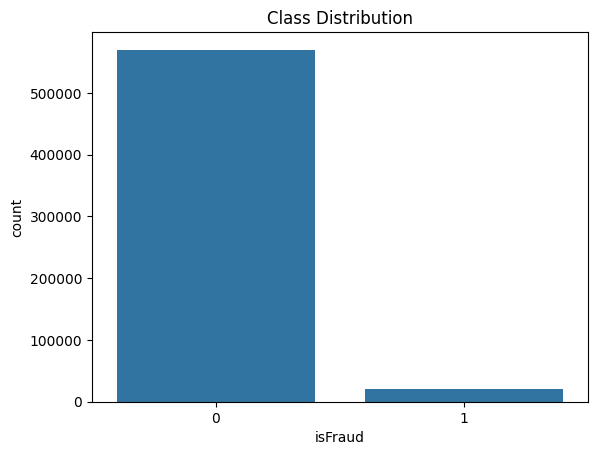

In [2]:
# ── Section 2: Target Variable ─────────────────
# Class imbalance — critical for fraud detection
print(trans['isFraud'].value_counts())
print(trans['isFraud'].value_counts(normalize=True))

# Expected: ~96.5% not fraud, ~3.5% fraud
sns.countplot(x='isFraud', data=trans)
plt.title('Class Distribution')
plt.show()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


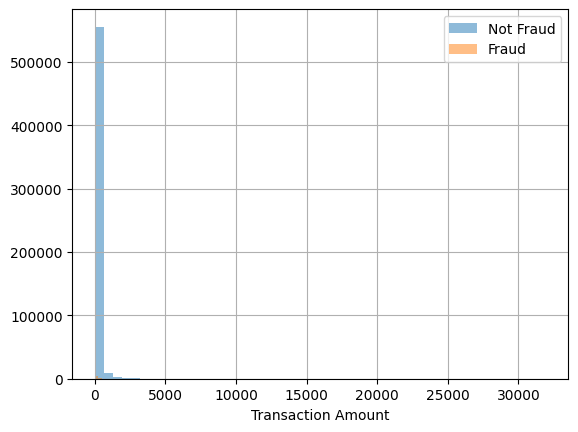

In [3]:
# ── Section 3: Transaction Amount ──────────────
print(trans['TransactionAmt'].describe())

# Distribution of fraud vs non-fraud amounts
trans.groupby('isFraud')['TransactionAmt'].hist(bins=50, alpha=0.5)
plt.xlabel('Transaction Amount')
plt.legend(['Not Fraud', 'Fraud'])
plt.show()

In [4]:
# ── Section 4: Key Columns for Features ────────
# These are the columns we'll use for streaming features
key_cols = ['TransactionID', 'TransactionDT', 'TransactionAmt',
            'card1', 'card2', 'card4', 'card6',
            'P_emaildomain', 'R_emaildomain',
            'isFraud']

print(trans[key_cols].describe())
print(trans[key_cols].isnull().sum())

       TransactionID  TransactionDT  TransactionAmt          card1  \
count   5.905400e+05   5.905400e+05   590540.000000  590540.000000   
mean    3.282270e+06   7.372311e+06      135.027176    9898.734658   
std     1.704744e+05   4.617224e+06      239.162522    4901.170153   
min     2.987000e+06   8.640000e+04        0.251000    1000.000000   
25%     3.134635e+06   3.027058e+06       43.321000    6019.000000   
50%     3.282270e+06   7.306528e+06       68.769000    9678.000000   
75%     3.429904e+06   1.124662e+07      125.000000   14184.000000   
max     3.577539e+06   1.581113e+07    31937.391000   18396.000000   

               card2        isFraud  
count  581607.000000  590540.000000  
mean      362.555488       0.034990  
std       157.793246       0.183755  
min       100.000000       0.000000  
25%       214.000000       0.000000  
50%       361.000000       0.000000  
75%       512.000000       0.000000  
max       600.000000       1.000000  
TransactionID          0
Tr

In [5]:
# ── Section 5: Missing Values Summary ──────────
missing = trans.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(trans) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

# Columns with >50% missing — we'll drop these
drop_cols = missing_df[missing_df['missing_pct'] > 50].index.tolist()
print(f"Columns to drop (>50% missing): {len(drop_cols)}")
print(drop_cols)

Columns to drop (>50% missing): 174
['dist2', 'D7', 'D13', 'D14', 'D12', 'D6', 'D9', 'D8', 'V153', 'V149', 'V141', 'V146', 'V154', 'V162', 'V142', 'V158', 'V161', 'V157', 'V138', 'V139', 'V148', 'V140', 'V155', 'V156', 'V147', 'V163', 'V143', 'V145', 'V144', 'V165', 'V164', 'V152', 'V150', 'V151', 'V160', 'V159', 'V166', 'V329', 'V328', 'V326', 'V327', 'V325', 'V331', 'V330', 'V333', 'V323', 'V324', 'V322', 'V339', 'V338', 'V335', 'V334', 'V332', 'V336', 'V337', 'V269', 'V275', 'V277', 'V276', 'V267', 'V268', 'V278', 'V273', 'V274', 'V265', 'V264', 'V263', 'V262', 'V261', 'V246', 'V247', 'V248', 'V249', 'V252', 'V253', 'V254', 'V258', 'V257', 'V260', 'V266', 'V218', 'V217', 'V219', 'V223', 'V224', 'V241', 'V242', 'V243', 'V240', 'V244', 'V237', 'V236', 'V235', 'V233', 'V232', 'V231', 'V230', 'V229', 'V228', 'V226', 'V225', 'R_emaildomain', 'V216', 'V213', 'V215', 'V212', 'V168', 'V199', 'V193', 'V192', 'V187', 'V211', 'V177', 'V214', 'V178', 'V173', 'V172', 'V183', 'V181', 'V179', 'V18

In [6]:
# ── Section 6: Save processed schema info ──────
# Save the columns we'll actually use
usable_cols = [col for col in trans.columns if col not in drop_cols]
pd.Series(usable_cols).to_csv('usable_columns.csv', index=False)
print(f"Usable columns: {len(usable_cols)}")

Usable columns: 220
